# Final comparison

Four questions, answered from the saved `benchmark_report_*.json` files (no inference is run here):

1. **Context vs no context**: raw function (function-only) vs CPG context, for both context strategies
   (`cpg_structural`, `multiplicative_amplification`), each with root static findings off/on.
2. **Static analyzers vs CPG context**: a static-analyzer-only predictor (vulnerable if any root
   Bandit/Dlint/Semgrep finding) vs the LLM with CPG context.
3. **Ranking strategies**: `cpg_structural` vs `multiplicative_amplification` on the main set, plus the
   full ranking sweep (all strategies vs a `dummy` baseline) from the compare-rankings runs.
4. **Fit for a secure development process on 16 GB**: covered by a separate experiment.

**Statistics for 1-3.** Every test is a paired exact McNemar test on per-sample correctness
(the two conditions are joined sample-for-sample). Holm correction is applied over the planned
comparisons, per question (`HOLM_SCOPE = "per_question"`) or over all of them (`"global"`).
**Core metrics** (ГОСТ Р 71207-2024, shown in %):
- доля ложноположительных срабатываний (п. 10.4), **FDR = 100 % · FP / (TP + FP)**: share of
  "vulnerable" verdicts that are false alarms;
- доля ложноотрицательных срабатываний (п. 10.5), **FNR = 100 % · FN / (TP + FN)**: share of truly
  vulnerable samples the model missed.

**Acceptance (п. 8.4):** a condition passes when FDR < 50 % and FNR < 50 % (point estimates); the stricter
column also requires both upper Wilson 95 % bounds to be below 50 %. A condition that never says
"vulnerable" has no FDR and fails.
**Optional metrics:** specificity TN / (TN + FP), accuracy, and the phi coefficient
(phi = (TP·TN − FP·FN) / √((TP+FP)(TP+FN)(TN+FP)(TN+FN))).

**Switching setups.** Change `MODEL`, `SETUP`, `PROMPT` and `RANKING` in the config cell and re-run
all cells. The "Available runs" cells list what exists on disk.

In [19]:
import fnmatch
import functools
import json
import math
import textwrap
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from scipy.stats import binomtest
from statsmodels.stats.contingency_tables import cochrans_q
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results").is_dir() and (p / "src").is_dir()), None
)
if ROOT is None:
    raise RuntimeError("run this notebook from inside the llm4codesec-framework checkout")
RESULTS = ROOT / "results"
pd.set_option("display.max_columns", 40, "display.width", 200, "display.max_colwidth", 80)

## Config

`SETUPS` maps each role (`function_only`, `cpg_off`, `cpg_on`, `mult_off`, `mult_on`) to a condition
directory. `plans` is searched in order; the first plan that has the condition for `MODEL`/prompt wins
(the target-split sweeps reuse the function-only report from another plan, for example).

In [20]:
# ---- what to compare -------------------------------------------------------------------------
MODEL = "gemma4-12b-it-thinking-sc3-logprobs-seeded-16k"  # or "lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded"
SETUP = "v2_root_context_thinking"  # key of SETUPS
PROMPT = None  # None = the setup's default prompt

# Ranking sweep for question 3 (see "Available ranking sweeps" below for other options).
RANKING = dict(
    plan="context_assembler_compare_rankings_experiments/context_sizes_gemma",
    model="gemma4-12b-it-thinking",
    prompt="strict_exploitable_security",
    suffix="_4k",  # context-size suffix of the condition names; "" for plans without sizes
    baseline="dummy",
    exclude=["smoke_test"],
)

# ---- statistics ------------------------------------------------------------------------------
ALPHA = 0.05
MAX_FDR = 0.5  # acceptance, ГОСТ п. 10.4: FP / (TP + FP) below this
MAX_FNR = 0.5  # acceptance: FN / (TP + FN) below this
HOLM_SCOPE = "per_question"  # or "global"
EXCLUDE_AUDITED_LABELS = True  # drop the 18 audited wrong labels (exclude_samples in the datasets config)
FAILED_PREDICTION = "wrong"  # failed/unparsed predictions count as errors ("wrong") or are dropped ("drop")

# ---- static-analyzer predictor (question 2) ---------------------------------------------------
SA_EXCLUDE_RULES = []  # fnmatch on rule_id, e.g. ["B101", "B113"]
SA_TOOLS = None  # None = all tools, or e.g. {"bandit", "semgrep"}; applies to the "all analyzers" row
Q2_BASE = None  # LLM condition the analyzers are compared with; None = the most accurate one in the setup

_V1_CONDS = dict(
    function_only="cleanvul_python_matched_root_findings",
    cpg_off="cpg_structural_root_findings_off",
    cpg_on="cpg_structural_root_findings_on",
    mult_off="mult_amp_root_findings_off",
    mult_on="mult_amp_root_findings_on",
)
_TARGET_CONDS = dict(
    function_only="cleanvul_python_matched_root_findings",
    cpg_off="cpg_structural_target_findings_off",
    cpg_on="cpg_structural_target_findings_on",
    mult_off="mult_amp_target_findings_off",
    mult_on="mult_amp_target_findings_on",
)
_V2_CONDS = dict(
    function_only="cleanvul_python_matched_v2_root",
    cpg_off="cpg_structural_v2_findings_off",
    cpg_on="cpg_structural_v2_findings_on",
    mult_off="mult_amp_v2_findings_off",
    mult_on="mult_amp_v2_findings_on",
)
SETUPS = {
    # v1: flat comment-stripped context, nothing marks the function under test
    "v1_flat": dict(
        plans=["static_findings_root/static_findings_root_sweep"],
        prompt="strict_exploitable_security_root_findings",
        conditions=_V1_CONDS,
    ),
    # v1 target/context split, strict prompt
    "v1_target_split": dict(
        plans=[
            "static_findings_root/static_findings_target_sweep",
            "static_findings_root/static_findings_lfm_sweep",
            "static_findings_root/static_findings_root_sweep",
        ],
        prompt="strict_exploitable_security_root_findings",
        conditions=_TARGET_CONDS,
    ),
    # v1 target/context split, v2 security prompt
    "v1_target_split_v2prompt": dict(
        plans=["static_findings_root/static_findings_v2_sweep", "static_findings_root/static_findings_lfm_sweep"],
        prompt="strict_exploitable_security_v2_root_findings",
        conditions=_TARGET_CONDS,
    ),
    # dataset v2: per-root ROOT / REFERENCE CONTEXT sections
    # gemma: the complete Oct 1 sweep (SC=7, 8k output), renamed to *_nothinking_20261001
    "v2_root_context": dict(
        plans=["root_context_v2/root_context_v2_gemma_sweep_nothinking_20261001",
               "root_context_v2/root_context_v2_lfm_sweep"],
        prompt="root_context_security_v2_root_findings",
        conditions=_V2_CONDS,
    ),
    # gemma thinking re-run (SC=3, 16k output); same model directory name, different run config
    "v2_root_context_thinking": dict(
        plans=["root_context_v2/root_context_v2_gemma_sweep"],
        prompt="root_context_security_v2_root_findings",
        conditions=_V2_CONDS,
    ),
    "v3_root_context": dict(
        plans=["root_context_v2/root_context_v3_lfm_sweep"],
        prompt="root_context_security_v3_root_findings",
        conditions=_V2_CONDS,
    ),
}
ROLE_LABELS = {
    "function_only": "function-only",
    "cpg_off": "CPG-structural",
    "cpg_on": "CPG-structural + SA findings",
    "mult_off": "mult-amp",
    "mult_on": "mult-amp + SA findings",
    "static_analyzer": "static analyzers only",
    "sa_bandit": "Bandit",
    "sa_dlint": "Dlint",
    "sa_semgrep": "Semgrep",
}

# ---- Russian labels for figures ------------------------------------------------------------
ROLE_LABELS_RU = {
    "function-only": "Только функция",
    "CPG-structural": "CPG-структурный контекст",
    "CPG-structural + SA findings": "CPG-структурный контекст + статический анализ",
    "mult-amp": "Мультипликативное усиление",
    "mult-amp + SA findings": "Мультипликативное усиление + статический анализ",
    "static analyzers only": "Все статические анализаторы",
}
STRATEGY_LABELS_RU = {
    "cpg_structural": "По типам ребёр CPG",
    "current": "Линейное",
    "current_default": "Линейное (вручную)",
    "depth_repeats_context": "Глубина и повторы",
    "dummy": "Без ранжирования",
    "evidence_budgeted": "Доказательства с ограничением бюджета",
    "multiplicative_boost": "Мультипликативное усиление",
    "multiplicative_boost_default": "Мультипликативное усиление (вручную)",
    "multiplicative_amplification": "Мультипликативное усиление",
    "multiplicative_amplification_default": "Мультипликативное усиление (вручную)",
    "random_picking": "Случайный выбор",
}


def ru(name):
    """Russian label for a condition or ranking strategy; '_last' variants get '(последние)'."""
    if name in ROLE_LABELS_RU:
        return ROLE_LABELS_RU[name]
    base, last = (name[:-5], True) if name.endswith("_last") else (name, False)
    label = STRATEGY_LABELS_RU.get(base, name)
    return f"{label} (последние)" if last else label


def ru_lower(name):
    """ru() for mid-sentence use: lower-case the first letter unless it is Latin (CPG, Bandit)."""
    label = ru(name)
    return label if label[:2].isupper() or label[0].isascii() else label[0].lower() + label[1:]

## Report index

In [21]:
def _index(pattern):
    rows = []
    for f in RESULTS.rglob(pattern):
        parts = f.relative_to(RESULTS).parts
        if len(parts) < 5:
            continue
        rows.append(
            dict(
                plan="/".join(parts[:-4]),
                condition=parts[-4],
                model=parts[-3],
                prompt=parts[-2],
                timestamp=f.stem.rsplit("_", 2)[-2] + "_" + f.stem.rsplit("_", 2)[-1],
                path=f,
            )
        )
    return pd.DataFrame(rows)


INDEX = _index("benchmark_report_*.json")
print(f"{len(INDEX)} benchmark reports under {RESULTS}")

1296 benchmark reports under /var/opt/llm4codesec-framework/results


### Available runs for the main setups
One row per (plan, model, prompt), with the number of distinct conditions. Use it to pick `MODEL` / `SETUP` / `PROMPT`.

In [22]:
_setup_plans = sorted({p for s in SETUPS.values() for p in s["plans"]})
(
    INDEX[INDEX.plan.isin(_setup_plans)]
    .groupby(["plan", "model", "prompt"])
    .condition.agg(n_conditions="nunique", conditions=lambda c: ", ".join(sorted(set(c))))
)

n_conditions  \
plan                                                            model                                          prompt                                                       
root_context_v2/root_context_v2_gemma_sweep                     gemma4-12b-it-thinking-sc3-logprobs-seeded-16k root_context_security_v2_root_findings                   4   
root_context_v2/root_context_v2_gemma_sweep_nothinking_20261001 gemma4-12b-it-thinking-sc7-logprobs-seeded     root_context_security_v2_root_findings                   5   
root_context_v2/root_context_v2_lfm_sweep                       lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded     root_context_security_v2_root_findings                   5   
root_context_v2/root_context_v3_lfm_sweep                       lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded     root_context_security_v3_root_findings                   5   
static_findings_root/static_findings_lfm_sweep                  lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded     strict_exploitable_security_root_findings                5   
                                                                                                               strict_exploitable_security_v2_root_findings             5   
static_findings_root/static_findings_root_sweep                 gemma4-12b-it-thinking-sc7-logprobs-seeded     strict_exploitable_security_root_findings                5   
static_findings_root/static_findings_target_sweep               gemma4-12b-it-thinking-sc7-logprobs-seeded     strict_exploitable_security_root_findings                4   
static_findings_root/static_findings_v2_sweep                   gemma4-12b-it-thinking-sc7-logprobs-seeded     strict_exploitable_security_v2_root_findings             5   

                                                                                                                                                                                                                                  conditions  
plan                                                            model                                          prompt                                                                                                                         
root_context_v2/root_context_v2_gemma_sweep                     gemma4-12b-it-thinking-sc3-logprobs-seeded-16k root_context_security_v2_root_findings        cleanvul_python_matched_v2_root, cpg_structural_v2_findings_off, cpg_structu...  
root_context_v2/root_context_v2_gemma_sweep_nothinking_20261001 gemma4-12b-it-thinking-sc7-logprobs-seeded     root_context_security_v2_root_findings        cleanvul_python_matched_v2_root, cpg_structural_v2_findings_off, cpg_structu...  
root_context_v2/root_context_v2_lfm_sweep                       lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded     root_context_security_v2_root_findings        cleanvul_python_matched_v2_root, cpg_structural_v2_findings_off, cpg_structu...  
root_context_v2/root_context_v3_lfm_sweep                       lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded     root_context_security_v3_root_findings        cleanvul_python_matched_v2_root, cpg_structural_v2_findings_off, cpg_structu...  
static_findings_root/static_findings_lfm_sweep                  lfm2.5-8b-a1b-thinking-sc7-logprobs-seeded     strict_exploitable_security_root_findings     cleanvul_python_matched_root_findings, cpg_structural_target_findings_off, c...  
                                                                                                               strict_exploitable_security_v2_root_findings  cleanvul_python_matched_root_findings, cpg_structural_target_findings_off, c...  
static_findings_root/static_findings_root_sweep                 gemma4-12b-it-thinking-sc7-logprobs-seeded     strict_exploitable_security_root_findings     cleanvul_python_matched_root_findings, cpg_structural_root_findings_off, cpg...  
static_findings_root/static_findings_target_sweep               gemma4-12b-it-thinking-sc7-logprobs-se

### Available ranking sweeps
Strategies per (plan, model, prompt, size suffix). Use it to fill `RANKING`.

In [23]:
_rk = INDEX[INDEX.plan.str.startswith("context_assembler_compare_rankings_experiments/")].copy()
_rk["suffix"] = _rk.condition.str.extract(r"(_\d+k)$", expand=False).fillna("")
_rk["strategy"] = [
    c.removeprefix("context_assembler_compare_").removesuffix(s) for c, s in zip(_rk.condition, _rk.suffix)
]
_rk.groupby(["plan", "model", "prompt", "suffix"]).strategy.agg(
    n_strategies="nunique", has_dummy=lambda s: "dummy" in set(s)
).query("n_strategies >= 3")

n_strategies  has_dummy
plan                                                                            model                            prompt                      suffix                         
context_assembler_compare_rankings_experiments/context_sizes                    gemma4-12b-it-thinking           strict_exploitable_security _16k               9       True
                                                                                                                                             _1k                9       True
                                                                                                                                             _2k                9       True
                                                                                                                                             _4k                9       True
                                                                                                                                             _8k                9       True
                                                                                gemma4-26b-a4b-gguf              strict_exploitable_security _16k               3      False
                                                                                                                                             _1k                3      False
                                                                                                                                             _2k                3      False
                                                                                                                                             _4k                3      False
                                                                                                                                             _8k                3      False
                                                                                gemma4-e4b-it                    strict_exploitable_security _16k               3      False
                                                                                                                                             _1k                3      False
                                                                                                                                             _2k                3      False
                                                                                                                                             _4k                3      False
                                                                                                                                             _8k                3      False
                                                                                qwen3-14b-gguf-thinking          strict_exploitable_security _16k               3      False
                                                                                                                                             _1k                3      False
                                                                                                                                             _2k                3      False
                                                                                                                                             _4k                3      False
                                                                                                                                             _8k                3      False
                                                                                qwen3-30b-a3b-instruct-gguf      strict_exploitable_security _16k               3      False
                                                                                                                                             _1k                3      Fal

## Loading and pairing

Join key: the CleanVul `source_row_ids` plus the label when the report stores them (all static-findings
and v2 runs), so conditions built from different dataset files pair correctly. Older compare-rankings
reports only have `sample_id`, and those IDs were re-randomized on every dataset regeneration, so they
are paired only **within one plan directory** and any ID whose label disagrees across strategies is
dropped (see `rank_load`).

In [24]:
def _row_key(rows, y):
    return f"rows={','.join(map(str, sorted(rows)))}|y={y}"


@functools.lru_cache(maxsize=None)
def load_report(path):
    with open(path) as fh:
        d = json.load(fh)
    recs = []
    for r in d["predictions"]:
        inf = r.get("inference_data") or {}
        y = int(r["true_label"])
        p = r.get("predicted_label")
        p = int(p) if r.get("is_success") and p in (0, 1) else None
        votes = {str(k): v for k, v in (inf.get("vote_counts") or {}).items()}
        n_votes = sum(votes.values())
        rows = r.get("source_row_ids")
        recs.append(
            dict(
                sample_id=r["sample_id"],
                key=_row_key(rows, y) if rows else f"id={r['sample_id']}",
                key_kind="source_rows" if rows else "sample_id",
                y=y,
                pred=p,
                vote_vuln=votes.get("1", 0) / n_votes if n_votes else np.nan,
                findings=r.get("root_static_findings"),
                prompt_tokens=inf.get("prompt_tokens"),
            )
        )
    df = pd.DataFrame(recs)
    dup = df.key.duplicated()
    if dup.any():
        warnings.warn(f"{path}: {dup.sum()} duplicate keys dropped")
        df = df[~dup]
    return df.set_index("key"), d["benchmark_info"]


def audited_keys():
    cfg = json.loads((ROOT / "src/configs/static_findings_root/datasets.json").read_text())
    ds = cfg.get("datasets", cfg)
    excl = next(v["exclude_samples"] for v in ds.values() if v.get("exclude_samples"))
    return {_row_key(e["source_row_ids"], e["label"]) for e in excl}


AUDITED = audited_keys() if EXCLUDE_AUDITED_LABELS else set()


def find_report(plans, condition, model, prompt):
    m = INDEX[
        (INDEX.condition == condition) & (INDEX.model == model) & (INDEX.prompt == prompt) & INDEX.plan.isin(plans)
    ]
    if m.empty:
        return None
    order = {p: i for i, p in enumerate(plans)}
    return m.assign(_o=m.plan.map(order)).sort_values(["_o", "timestamp"], ascending=[True, False]).iloc[0]


def load_setup(setup, model, prompt=None):
    s = SETUPS[setup]
    prompt = prompt or s["prompt"]
    frames, prov = {}, []
    for role, cond in s["conditions"].items():
        hit = find_report(s["plans"], cond, model, prompt)
        if hit is None:
            warnings.warn(f"{setup}/{role}: no report for {cond} / {model} / {prompt}")
            continue
        df, info = load_report(hit.path)
        n_raw = len(df)
        df = df[~df.index.isin(AUDITED)]
        frames[role] = df
        m = info["model"]
        prov.append(
            dict(
                role=role,
                plan=hit.plan,
                condition=cond,
                timestamp=hit.timestamp,
                n=n_raw,
                n_after_audit=len(df),
                failed=int(df.pred.isna().sum()),
                sc=m.get("self_consistency_samples"),
                max_output_tokens=m.get("max_output_tokens"),
                seed=m.get("sampling_seed"),
                temperature=m.get("temperature"),
                prompt_sha=(info.get("prompt_template_sha256") or "")[:12],
            )
        )
    if not prov:
        raise ValueError(f"{setup}: no reports for model {model!r} / prompt {prompt!r} in {s['plans']}")
    prov = pd.DataFrame(prov).set_index("role")
    run_cfg = ["sc", "max_output_tokens", "seed", "temperature", "prompt_sha"]
    if len(prov[run_cfg].astype(str).drop_duplicates()) > 1:
        warnings.warn(f"{setup}: conditions come from different run configurations, see PROVENANCE {run_cfg}")
    return frames, prov


def align(frames):
    """Wide frame over the keys present in every condition: y, pred_<role>, correct_<role>."""
    keys = None
    for df in frames.values():
        keys = df.index if keys is None else keys.intersection(df.index)
    wide = pd.DataFrame(index=keys)
    first = next(iter(frames.values()))
    wide["y"] = first.loc[keys, "y"]
    for role, df in frames.items():
        sub = df.loc[keys]
        if (sub.y != wide.y).any():
            raise ValueError(f"{role}: labels disagree on the joined keys")
        wide[f"pred_{role}"] = sub.pred
    if FAILED_PREDICTION == "drop":
        wide = wide.dropna(subset=[c for c in wide if c.startswith("pred_")])
    for role in frames:
        p = wide[f"pred_{role}"]
        wide[f"eff_{role}"] = p.fillna(1 - wide.y).astype(int)  # a failed prediction is an error
        wide[f"correct_{role}"] = wide[f"eff_{role}"] == wide.y
    return wide

## Metrics and tests

In [25]:
def _ci(k, n):
    if n == 0:
        return (np.nan, np.nan)
    return proportion_confint(k, n, alpha=ALPHA, method="wilson")


def binary_metrics(y, p):
    y, p = np.asarray(y), np.asarray(p)
    tp = int(((y == 1) & (p == 1)).sum())
    tn = int(((y == 0) & (p == 0)).sum())
    fp = int(((y == 0) & (p == 1)).sum())
    fn = int(((y == 1) & (p == 0)).sum())
    n, neg = len(y), tn + fp
    fdr = fp / (tp + fp) if tp + fp else np.nan
    fdr_lo, fdr_hi = _ci(fp, tp + fp)
    fnr = fn / (tp + fn) if tp + fn else np.nan
    fnr_lo, fnr_hi = _ci(fn, tp + fn)
    acc_lo, acc_hi = _ci(tp + tn, n)
    denom = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    return dict(
        n=n,
        fdr=fdr,
        fdr_lo=fdr_lo,
        fdr_hi=fdr_hi,
        fnr=fnr,
        fnr_lo=fnr_lo,
        fnr_hi=fnr_hi,
        accept=bool(fdr < MAX_FDR and fnr < MAX_FNR),  # NaN (nothing flagged) fails
        accept_strict=bool(fdr_hi < MAX_FDR and fnr_hi < MAX_FNR),
        specificity=tn / neg if neg else np.nan,
        accuracy=(tp + tn) / n,
        acc_lo=acc_lo,
        acc_hi=acc_hi,
        phi=(tp * tn - fp * fn) / denom if denom else 0.0,
        tp=tp,
        fp=fp,
        tn=tn,
        fn=fn,
    )


PCT_COLS = ["fdr", "fdr_lo", "fdr_hi", "fnr", "fnr_lo", "fnr_hi"]
CORE_COLS = ["n", "fdr", "fdr_lo", "fdr_hi", "fnr", "fnr_lo", "fnr_hi", "accept", "accept_strict",
             "specificity", "accuracy", "phi"]


def fmt_metrics(df):
    """Core rates in %, everything else to 3 decimals."""
    pct = [c for c in PCT_COLS if c in df]
    return df.style.format(precision=3).format(lambda v: f"{v * 100:.1f} %" if pd.notna(v) else "n/a", subset=pct)


def metrics_table(wide, roles):
    out = {r: binary_metrics(wide.y, wide[f"eff_{r}"]) for r in roles}
    return pd.DataFrame(out).T.rename(index=ROLE_LABELS)


def mcnemar(correct_a, correct_b):
    """Exact McNemar on paired correctness. b = only A right, c = only B right; delta = acc(B) - acc(A)."""
    a, b_ = np.asarray(correct_a, bool), np.asarray(correct_b, bool)
    n = len(a)
    b = int((a & ~b_).sum())
    c = int((~a & b_).sum())
    p = binomtest(min(b, c), b + c, 0.5).pvalue if b + c else 1.0
    delta = (c - b) / n
    se = math.sqrt(max((b + c) - (c - b) ** 2 / n, 0)) / n
    z = 1.959963984540054
    return dict(n=n, only_a=b, only_b=c, delta_acc=delta, delta_lo=delta - z * se, delta_hi=delta + z * se, p=p)


TESTS = []  # every planned comparison, collected across questions


def run_family(question, wide, pairs, labels=ROLE_LABELS):
    rows = []
    for a, b in pairs:
        if f"correct_{a}" not in wide or f"correct_{b}" not in wide:
            warnings.warn(f"{question}: skipping {a} vs {b} (condition missing)")
            continue
        r = mcnemar(wide[f"correct_{a}"], wide[f"correct_{b}"])
        rows.append(dict(question=question, A=labels.get(a, a), B=labels.get(b, b), **r))
    fam = pd.DataFrame(rows)
    if fam.empty:
        print(f"{question}: no comparison possible, every pair needs a condition this setup lacks")
        TESTS[:] = [t for t in TESTS if t["question"] != question]
        return fam
    fam["p_holm"] = multipletests(fam.p, method="holm")[1]
    fam["significant"] = fam.p_holm < ALPHA
    TESTS[:] = [t for t in TESTS if t["question"] != question] + fam.to_dict("records")
    return fam


def show_tests(fam):
    if not fam.empty:
        display(fam.style.format(precision=3, subset=["delta_acc", "delta_lo", "delta_hi", "p", "p_holm"]))


def forest(fam, title):
    if fam.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 0.6 * len(fam) + 1.4))
    ypos = np.arange(len(fam))[::-1]
    for yv, (_, r) in zip(ypos, fam.iterrows()):
        ax.plot([r.delta_lo, r.delta_hi], [yv, yv], color="#4a4a4a", lw=2, solid_capstyle="round")
        ax.plot(
            r.delta_acc, yv, "o", ms=9, color="#0072B2", mfc="#0072B2" if r.significant else "white", mew=2
        )
        ax.annotate(f"p (Холм) = {r.p_holm:.3g}", (r.delta_hi, yv), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=8, color="#4a4a4a")
    ax.axvline(0, color="#9a9a9a", lw=1)
    # one shared base (named in the title): label rows by B only
    one_base = fam.A.nunique() == 1
    ax.set_yticks(ypos, [textwrap.fill(ru(r.B) if one_base else f"{ru(r.B)} vs {ru_lower(r.A)}", 36)
                         for _, r in fam.iterrows()])
    ax.set_xlabel("Δ точности (B − A), 95 % ДИ\n● закрашен — значимо после поправки Холма")
    ax.set_title(textwrap.fill(title, 70), loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#e5e5e5", lw=0.8)
    plt.tight_layout()
    plt.show()


def error_rate_plot(mt, title):
    """FDR and FNR (ГОСТ Р 71207-2024) per condition with Wilson 95 % intervals; both must sit left of the limit."""
    fig, ax = plt.subplots(figsize=(8, 0.45 * len(mt) + 1.4))
    ypos = np.arange(len(mt))[::-1]
    for (name, r), yv in zip(mt.iterrows(), ypos):
        for val, lo, hi, dy, marker, color in [(r.fdr, r.fdr_lo, r.fdr_hi, 0.12, "o", "#0072B2"),
                                               (r.fnr, r.fnr_lo, r.fnr_hi, -0.12, "s", "#D55E00")]:
            if pd.isna(val):
                continue
            ax.plot([lo * 100, hi * 100], [yv + dy] * 2, color=color, lw=1.5, alpha=0.6)
            ax.plot(val * 100, yv + dy, marker, ms=7, color=color)
        ax.annotate("проходит" if r.accept else "не проходит", (100, yv), xytext=(6, 0),
                    textcoords="offset points", va="center", fontsize=8, color="#4a4a4a")
    ax.axvline(MAX_FDR * 100, color="#4a4a4a", lw=1, ls="--")
    if MAX_FNR != MAX_FDR:
        ax.axvline(MAX_FNR * 100, color="#9a9a9a", lw=1, ls=":")
    ax.set_yticks(ypos, [textwrap.fill(ru(n), 30) for n in mt.index])
    ax.set_xlim(0, 100)
    ax.plot([], [], "o", color="#0072B2", label="Доля ложноположительных = FP / (TP + FP)")
    ax.plot([], [], "s", color="#D55E00", label="Доля ложноотрицательных = FN / (TP + FN)")
    ax.legend(loc="lower right", bbox_to_anchor=(1, 1), ncol=2, frameon=False, fontsize=8)
    ax.set_xlabel("%, 95%-ный ДИ; пунктир — граница допустимых значений")
    ax.set_title(textwrap.fill(title, 70), loc="left", pad=22)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#e5e5e5", lw=0.8)
    plt.tight_layout()
    plt.show()

## Load the selected setup

In [26]:
FRAMES, PROVENANCE = load_setup(SETUP, MODEL, PROMPT)
WIDE = align(FRAMES)
ROLES = list(FRAMES)
display(Markdown(f"**{SETUP}** · `{MODEL}` · prompt `{PROMPT or SETUPS[SETUP]['prompt']}` · "
                 f"{len(WIDE)} paired samples ({int(WIDE.y.sum())} vulnerable)"))
PROVENANCE

/tmp/ipykernel_776716/1931714853.py:65: UserWarning: v2_root_context_thinking/mult_on: no report for mult_amp_v2_findings_on / gemma4-12b-it-thinking-sc3-logprobs-seeded-16k / root_context_security_v2_root_findings
  warnings.warn(f"{setup}/{role}: no report for {cond} / {model} / {prompt}")


**v2_root_context_thinking** · `gemma4-12b-it-thinking-sc3-logprobs-seeded-16k` · prompt `root_context_security_v2_root_findings` · 710 paired samples (355 vulnerable)

,plan,condition,timestamp,n,n_after_audit,failed,sc,max_output_tokens,seed,temperature,prompt_sha
role,,,,,,,,,,,
function_only,root_context_v2/root_context_v2_gemma_sweep,cleanvul_python_matched_v2_root,20261004_083212,710,710,0,3,16384,20260925,1.0,694d2a14dda6
cpg_off,root_context_v2/root_context_v2_gemma_sweep,cpg_structural_v2_findings_off,20261004_172633,710,710,0,3,16384,20260925,1.0,694d2a14dda6
cpg_on,root_context_v2/root_context_v2_gemma_sweep,cpg_structural_v2_findings_on,20261005_115725,710,710,0,3,16384,20260925,1.0,694d2a14dda6
mult_off,root_context_v2/root_context_v2_gemma_sweep,mult_amp_v2_findings_off,20261005_024530,710,710,0,3,16384,20260925,1.0,694d2a14dda6


In [27]:
METRICS = metrics_table(WIDE, ROLES)
fmt_metrics(METRICS)

,n,fdr,fdr_lo,fdr_hi,fnr,fnr_lo,fnr_hi,accept,accept_strict,specificity,accuracy,acc_lo,acc_hi,phi,tp,fp,tn,fn
function-only,710,40.8 %,35.6 %,46.2 %,44.8 %,39.7 %,50.0 %,True,True,0.620,0.586,0.549,0.622,0.172,196,135,220,159
CPG-structural,710,38.4 %,33.3 %,43.8 %,43.9 %,38.9 %,49.1 %,True,True,0.651,0.606,0.569,0.641,0.212,199,124,231,156
CPG-structural + SA findings,710,37.6 %,32.5 %,42.9 %,42.0 %,37.0 %,47.2 %,True,True,0.651,0.615,0.579,0.651,0.232,206,124,231,149
mult-amp,710,37.8 %,32.6 %,43.4 %,46.8 %,41.6 %,52.0 %,True,False,0.676,0.604,0.568,0.640,0.211,189,115,240,166


## Q1 · Context vs no context

Planned comparisons: function-only vs each context condition (both strategies, findings off/on), and
findings off vs on within each strategy.

/tmp/ipykernel_776716/1295835336.py:78: UserWarning: Q1 context: skipping function_only vs mult_on (condition missing)
  warnings.warn(f"{question}: skipping {a} vs {b} (condition missing)")
/tmp/ipykernel_776716/1295835336.py:78: UserWarning: Q1 context: skipping mult_off vs mult_on (condition missing)
  warnings.warn(f"{question}: skipping {a} vs {b} (condition missing)")


,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,significant
0,Q1 context,function-only,CPG-structural,710,73,87,0.020,-0.015,0.055,0.304,0.912,False
1,Q1 context,function-only,mult-amp,710,78,91,0.018,-0.018,0.054,0.356,0.912,False
2,Q1 context,function-only,CPG-structural + SA findings,710,67,88,0.030,-0.005,0.064,0.108,0.432,False
3,Q1 context,CPG-structural,CPG-structural + SA findings,710,57,64,0.010,-0.020,0.040,0.586,0.912,False


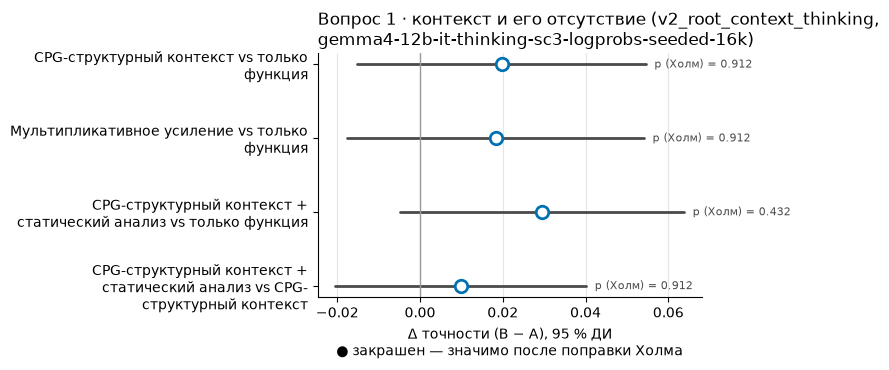

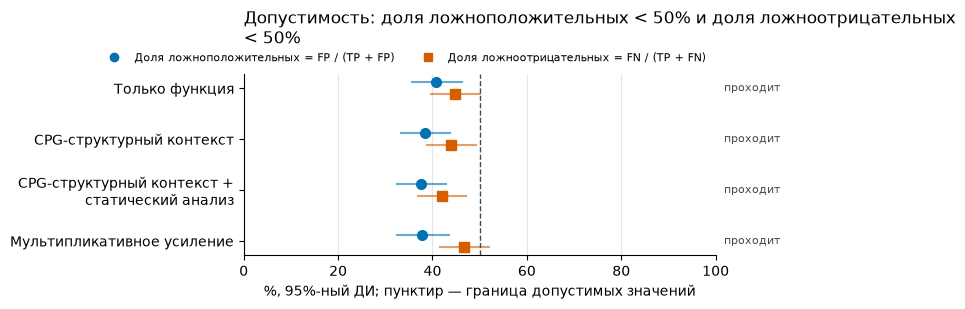

In [28]:
Q1_PAIRS = [
    ("function_only", "cpg_off"),
    ("function_only", "mult_off"),
    ("function_only", "cpg_on"),
    ("function_only", "mult_on"),
    ("cpg_off", "cpg_on"),
    ("mult_off", "mult_on"),
]
Q1 = run_family("Q1 context", WIDE, Q1_PAIRS)
show_tests(Q1)
forest(Q1, f"Вопрос 1 · контекст и его отсутствие ({SETUP}, {MODEL})")
error_rate_plot(METRICS, f"Допустимость: доля ложноположительных < {MAX_FDR:.0%} и доля ложноотрицательных < {MAX_FNR:.0%}")

## Q2 · Static analyzers vs CPG context

Base: the best LLM run of the setup (highest accuracy, or `Q2_BASE`). It is compared with each static
analyzer on its own (Bandit, Dlint, Semgrep) and with all of them together. An analyzer says *vulnerable*
when the sample has at least one root finding from it (only findings on the changed function, i.e.
`is_root`), after `SA_EXCLUDE_RULES`; "all analyzers" also honours `SA_TOOLS`. Findings are read from the
prediction records, so they are exactly what the `*_on` conditions showed the model.

Base for Q2: **CPG-структурный контекст + статический анализ** (accuracy 0.615)

,n,fdr,fdr_lo,fdr_hi,fnr,fnr_lo,fnr_hi,accept,accept_strict,specificity,accuracy,acc_lo,acc_hi,phi,tp,fp,tn,fn
CPG-structural + SA findings,710,37.6 %,32.5 %,42.9 %,42.0 %,37.0 %,47.2 %,True,True,0.651,0.615,0.579,0.651,0.232,206,124,231,149
Bandit,710,36.9 %,28.2 %,46.5 %,81.7 %,77.3 %,85.4 %,False,False,0.893,0.538,0.501,0.574,0.108,65,38,317,290
Dlint,710,36.6 %,26.4 %,48.2 %,87.3 %,83.5 %,90.4 %,False,False,0.927,0.527,0.490,0.563,0.089,45,26,329,310
Semgrep,710,40.0 %,27.6 %,53.8 %,91.5 %,88.2 %,94.0 %,False,False,0.944,0.514,0.477,0.551,0.055,30,20,335,325
static analyzers only,710,39.3 %,31.4 %,47.7 %,76.9 %,72.2 %,81.0 %,False,False,0.851,0.541,0.504,0.577,0.104,82,53,302,273


,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,significant
0,Q2 static analyzers,CPG-structural + SA findings,Bandit,710,167,112,-0.077,-0.123,-0.032,0.001,0.002,True
1,Q2 static analyzers,CPG-structural + SA findings,Dlint,710,181,118,-0.089,-0.136,-0.041,0.000,0.001,True
2,Q2 static analyzers,CPG-structural + SA findings,Semgrep,710,196,124,-0.101,-0.150,-0.053,0.000,0.000,True
3,Q2 static analyzers,CPG-structural + SA findings,static analyzers only,710,169,116,-0.075,-0.121,-0.028,0.002,0.002,True


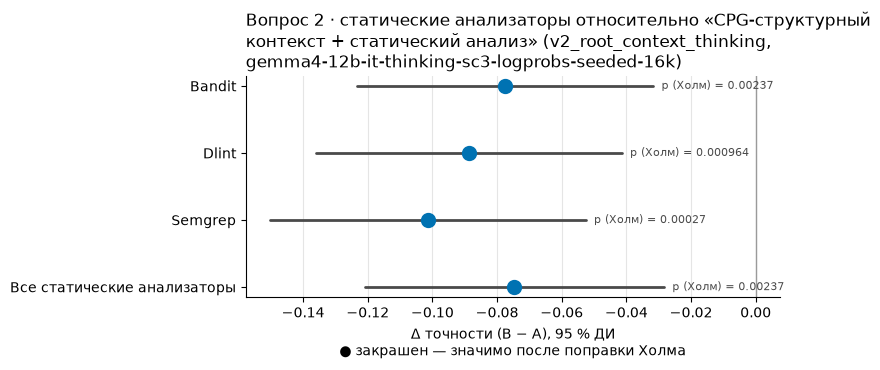

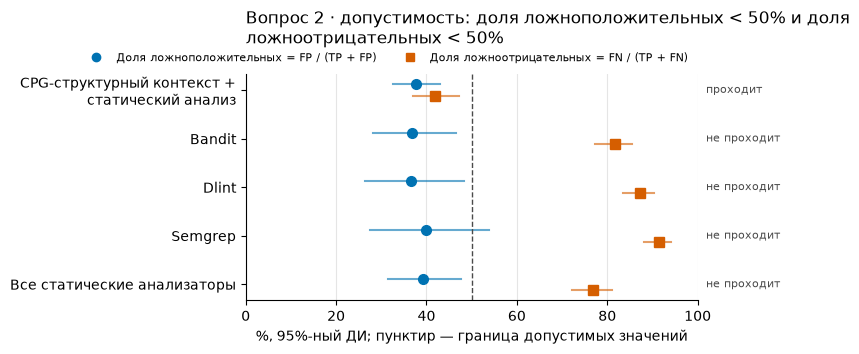

In [29]:
def sa_predict(findings, tools=None):
    if not isinstance(findings, list):
        return np.nan
    kept = [
        f for f in findings
        if (tools is None or f.get("tool") in tools)
        and not any(fnmatch.fnmatch(str(f.get("rule_id")), pat) for pat in SA_EXCLUDE_RULES)
    ]
    return int(bool(kept))


_src = next((r for r in ["cpg_on", "mult_on", "cpg_off", "mult_off", "function_only"]
             if r in FRAMES and FRAMES[r].findings.notna().any()), None)
if _src is None:
    raise RuntimeError("no condition in this setup stores root_static_findings")
_all_findings = FRAMES[_src].loc[WIDE.index, "findings"]
if _all_findings.isna().any():
    warnings.warn(f"{_all_findings.isna().sum()} samples without stored findings are treated as 'no finding'")
SA_ROLES = {"sa_bandit": {"bandit"}, "sa_dlint": {"dlint"}, "sa_semgrep": {"semgrep"}, "static_analyzer": SA_TOOLS}
for role, tools in SA_ROLES.items():
    WIDE[f"eff_{role}"] = _all_findings.map(lambda fs: sa_predict(fs, tools)).fillna(0).astype(int)
    WIDE[f"correct_{role}"] = WIDE[f"eff_{role}"] == WIDE.y

Q2_BASE_ROLE = Q2_BASE or max(ROLES, key=lambda r: WIDE[f"correct_{r}"].mean())
display(Markdown(f"Base for Q2: **{ru(ROLE_LABELS[Q2_BASE_ROLE])}** "
                 f"(accuracy {WIDE[f'correct_{Q2_BASE_ROLE}'].mean():.3f})"))
Q2_PAIRS = [(Q2_BASE_ROLE, r) for r in SA_ROLES]
Q2 = run_family("Q2 static analyzers", WIDE, Q2_PAIRS)
Q2_METRICS = metrics_table(WIDE, [Q2_BASE_ROLE] + list(SA_ROLES))
display(fmt_metrics(Q2_METRICS))
show_tests(Q2)
forest(Q2, f"Вопрос 2 · статические анализаторы относительно «{ru(ROLE_LABELS[Q2_BASE_ROLE])}» ({SETUP}, {MODEL})")
error_rate_plot(Q2_METRICS, f"Вопрос 2 · допустимость: доля ложноположительных < {MAX_FDR:.0%} и доля ложноотрицательных < {MAX_FNR:.0%}")

Which rules fire most (descriptive only).

In [30]:
_rules = pd.DataFrame(
    [dict(tool=f.get("tool"), rule_id=f.get("rule_id"), y=y)
     for fs, y in zip(_all_findings, WIDE.y) for f in (fs or [])]
)
if not _rules.empty:
    display(_rules.groupby(["tool", "rule_id"]).y.agg(findings="size", on_vulnerable="sum")
            .assign(share_on_vulnerable=lambda t: t.on_vulnerable / t.findings)
            .sort_values("findings", ascending=False).head(15))

findings  on_vulnerable  share_on_vulnerable
tool    rule_id                                                                                                                       
bandit  B113                                                                                    51             26             0.509804
semgrep python.lang.security.audit.insecure-transport.requests.request-with-http.requ...        36             18             0.500000
        python.lang.security.audit.subprocess-shell-true.subprocess-shell-true                  24             15             0.625000
bandit  B602                                                                                    23             14             0.608696
        B608                                                                                    23             21             0.913043
dlint   DUO116                                                                                  23             14             0.608696
        DUO109                                                                                  22             14             0.636364
bandit  B603                                                                                    20              6             0.300000
semgrep python.flask.security.injection.ssrf-requests.ssrf-requests                             20             10             0.500000
bandit  B605                                                                                    17              8             0.470588
        B202                                                                                    13              7             0.538462
        B506                                                                                    12             11             0.916667
semgrep python.lang.security.audit.logging.logger-credential-leak.python-logger-crede...        11              6             0.545455
dlint   DUO102                                                                                  11              6             0.545455
        DUO106                                                                                  11              4             0.363636

## Q3 · Ranking strategies

**3a, main set.** `cpg_structural` vs `multiplicative_amplification`, findings off and on (same pairing as Q1).

In [31]:
Q3A = run_family("Q3a ranking (main set)", WIDE, [("cpg_off", "mult_off"), ("cpg_on", "mult_on")])
show_tests(Q3A)

/tmp/ipykernel_776716/1295835336.py:78: UserWarning: Q3a ranking (main set): skipping cpg_on vs mult_on (condition missing)
  warnings.warn(f"{question}: skipping {a} vs {b} (condition missing)")


,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,significant
0,Q3a ranking (main set),CPG-structural,mult-amp,710,59,58,-0.001,-0.031,0.028,1.000,1.000,False


**3b, full ranking sweep** (`RANKING`). Cochran's Q tests whether any strategy differs at all; the
planned comparisons are every strategy vs `RANKING["baseline"]`, Holm-corrected. These runs predate
`source_row_ids`, so they pair by `sample_id` inside one plan directory, and IDs whose label differs
between strategies are dropped (a sign of mixed dataset generations).

`context_assembler_compare_rankings_experiments/context_sizes_gemma` · `gemma4-12b-it-thinking` · suffix `_4k` · 376 paired samples, 9 strategies · 0 label conflicts

,timestamp,n,n_reruns,sc
strategy,,,,
cpg_structural,20260626_012142,376,1,1
current,20260626_001652,376,1,1
current_default,20260626_010435,376,1,1
depth_repeats_context,20260626_002613,376,1,1
dummy,20260626_003628,376,1,1
evidence_budgeted,20260626_012934,376,1,1
multiplicative_boost,20260626_004548,376,1,1
multiplicative_boost_default,20260626_011354,376,1,1
random_picking,20260626_005509,376,1,1


,n,fdr,fdr_lo,fdr_hi,fnr,fnr_lo,fnr_hi,accept,accept_strict,specificity,accuracy,phi
evidence_budgeted,376,39.9 %,33.3 %,46.8 %,36.7 %,30.1 %,43.8 %,True,True,0.580,0.606,0.213
multiplicative_boost,376,42.1 %,35.6 %,48.9 %,35.6 %,29.1 %,42.7 %,True,True,0.532,0.588,0.177
current_default,376,43.0 %,36.7 %,49.5 %,30.9 %,24.7 %,37.8 %,True,True,0.479,0.585,0.174
multiplicative_boost_default,376,42.9 %,36.5 %,49.5 %,34.0 %,27.6 %,41.1 %,True,True,0.505,0.582,0.167
cpg_structural,376,42.6 %,35.9 %,49.6 %,39.9 %,33.2 %,47.0 %,True,True,0.553,0.577,0.154
dummy,376,43.4 %,36.9 %,50.1 %,36.2 %,29.6 %,43.3 %,True,False,0.511,0.574,0.150
current,376,44.5 %,38.2 %,51.0 %,32.4 %,26.2 %,39.4 %,True,False,0.457,0.566,0.136
random_picking,376,45.7 %,39.0 %,52.5 %,39.9 %,33.2 %,47.0 %,True,False,0.495,0.548,0.096
depth_repeats_context,376,46.6 %,40.0 %,53.4 %,41.0 %,34.2 %,48.1 %,True,False,0.484,0.537,0.075


Cochran's Q = 9.38, df = 8, p = 0.312

,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,significant
0,Q3b ranking sweep,dummy,cpg_structural,376,59,60,0.003,-0.054,0.060,1.000,1.000,False
1,Q3b ranking sweep,dummy,current,376,52,49,-0.008,-0.060,0.044,0.842,1.000,False
2,Q3b ranking sweep,dummy,current_default,376,50,54,0.011,-0.043,0.064,0.769,1.000,False
3,Q3b ranking sweep,dummy,depth_repeats_context,376,59,45,-0.037,-0.090,0.016,0.202,1.000,False
4,Q3b ranking sweep,dummy,evidence_budgeted,376,53,65,0.032,-0.025,0.088,0.311,1.000,False
5,Q3b ranking sweep,dummy,multiplicative_boost,376,54,59,0.013,-0.042,0.069,0.707,1.000,False
6,Q3b ranking sweep,dummy,multiplicative_boost_default,376,47,50,0.008,-0.043,0.059,0.839,1.000,False
7,Q3b ranking sweep,dummy,random_picking,376,59,49,-0.027,-0.081,0.028,0.387,1.000,False


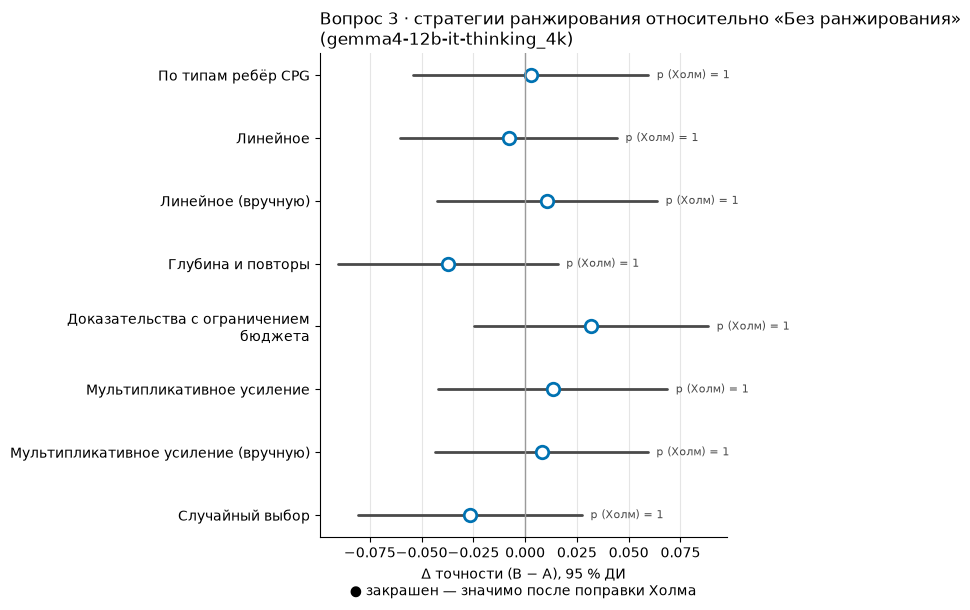

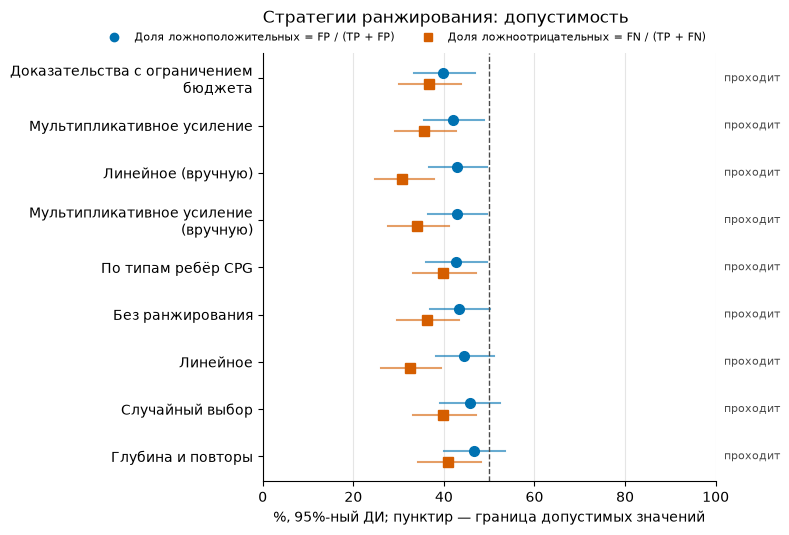

In [32]:
def rank_load(cfg):
    m = INDEX[(INDEX.plan == cfg["plan"]) & (INDEX.model == cfg["model"]) & (INDEX.prompt == cfg["prompt"])]
    frames, prov = {}, []
    for cond, g in m.groupby("condition"):
        if cfg["suffix"] and not cond.endswith(cfg["suffix"]):
            continue
        if not cfg["suffix"] and pd.Series([cond]).str.contains(r"_\d+k$").iloc[0]:
            continue
        strat = cond.removeprefix("context_assembler_compare_").removesuffix(cfg["suffix"])
        if strat in cfg.get("exclude", []):
            continue
        hit = g.sort_values("timestamp").iloc[-1]
        df, info = load_report(hit.path)
        frames[strat] = df
        prov.append(dict(strategy=strat, timestamp=hit.timestamp, n=len(df), n_reruns=len(g),
                         sc=info["model"].get("self_consistency_samples")))
    # labels must agree per key across strategies
    lab = pd.concat({s: f.y for s, f in frames.items()}, axis=1)
    conflict = lab.nunique(axis=1) > 1
    if conflict.any():
        warnings.warn(f"{conflict.sum()} sample ids have conflicting labels across strategies; dropped")
    keep = lab.index[~conflict & lab.notna().all(axis=1)]
    frames = {s: f.loc[f.index.intersection(keep)] for s, f in frames.items()}
    return frames, pd.DataFrame(prov).set_index("strategy"), int(conflict.sum())


RK_FRAMES, RK_PROV, RK_CONFLICTS = rank_load(RANKING)
RK_WIDE = align(RK_FRAMES)
RK = list(RK_FRAMES)
display(Markdown(f"`{RANKING['plan']}` · `{RANKING['model']}` · suffix `{RANKING['suffix'] or '-'}` · "
                 f"{len(RK_WIDE)} paired samples, {len(RK)} strategies"
                 + (f" · **{RK_CONFLICTS} ids dropped for conflicting labels: this sweep mixes dataset "
                    "generations, so even the kept ids may not pair the same code. Prefer a sweep with 0.**"
                    if RK_CONFLICTS else " · 0 label conflicts")))
display(RK_PROV)
RK_METRICS = metrics_table(RK_WIDE, RK).sort_values("accuracy", ascending=False)
display(fmt_metrics(RK_METRICS[CORE_COLS]))

_q = cochrans_q(RK_WIDE[[f"correct_{s}" for s in RK]].astype(int).values)
display(Markdown(f"Cochran's Q = {_q.statistic:.2f}, df = {len(RK) - 1}, p = {_q.pvalue:.3g}"))

base = RANKING["baseline"]
Q3B = run_family("Q3b ranking sweep", RK_WIDE, [(base, s) for s in RK if s != base], labels={})
show_tests(Q3B)
forest(Q3B, f"Вопрос 3 · стратегии ранжирования относительно «{ru(base)}» ({RANKING['model']}{RANKING['suffix']})")
error_rate_plot(RK_METRICS, "Стратегии ранжирования: допустимость")

## Summary of Q1-Q3
Holm correction over the scope chosen by `HOLM_SCOPE`. Q3a and Q3b are separate families when the scope
is per question.

In [33]:
SUMMARY = pd.DataFrame(TESTS, columns=["question", "A", "B", "n", "only_a", "only_b", "delta_acc", "delta_lo",
                                       "delta_hi", "p"])
if HOLM_SCOPE == "global":
    SUMMARY["p_holm"] = multipletests(SUMMARY.p, method="holm")[1]
else:
    SUMMARY["p_holm"] = SUMMARY.groupby("question").p.transform(lambda p: multipletests(p, method="holm")[1])
SUMMARY["significant"] = SUMMARY.p_holm < ALPHA
SUMMARY["verdict"] = np.where(
    ~SUMMARY.significant, "no significant difference",
    np.where(SUMMARY.delta_acc > 0, "B better", "A better"),
)
display(SUMMARY[["question", "A", "B", "n", "only_a", "only_b", "delta_acc", "delta_lo", "delta_hi", "p",
                 "p_holm", "verdict"]].style.format(precision=3, subset=["delta_acc", "delta_lo", "delta_hi",
                                                                         "p", "p_holm"]))
_acc = pd.concat([METRICS.assign(set=SETUP), RK_METRICS.assign(set="ranking sweep")])
display(fmt_metrics(_acc[["set", "n", "fdr", "fdr_hi", "fnr", "fnr_hi", "accept", "accept_strict",
                           "specificity", "accuracy", "phi"]]))

,question,A,B,n,only_a,only_b,delta_acc,delta_lo,delta_hi,p,p_holm,verdict
0,Q1 context,function-only,CPG-structural,710,73,87,0.020,-0.015,0.055,0.304,0.912,no significant difference
1,Q1 context,function-only,mult-amp,710,78,91,0.018,-0.018,0.054,0.356,0.912,no significant difference
2,Q1 context,function-only,CPG-structural + SA findings,710,67,88,0.030,-0.005,0.064,0.108,0.432,no significant difference
3,Q1 context,CPG-structural,CPG-structural + SA findings,710,57,64,0.010,-0.020,0.040,0.586,0.912,no significant difference
4,Q2 static analyzers,CPG-structural + SA findings,Bandit,710,167,112,-0.077,-0.123,-0.032,0.001,0.002,A better
5,Q2 static analyzers,CPG-structural + SA findings,Dlint,710,181,118,-0.089,-0.136,-0.041,0.000,0.001,A better
6,Q2 static analyzers,CPG-structural + SA findings,Semgrep,710,196,124,-0.101,-0.150,-0.053,0.000,0.000,A better
7,Q2 static analyzers,CPG-structural + SA findings,static analyzers only,710,169,116,-0.075,-0.121,-0.028,0.002,0.002,A better
8,Q3a ranking (main set),CPG-structural,mult-amp,710,59,58,-0.001,-0.031,0.028,1.000,1.000,no significant difference
9,Q3b ranking sweep,dummy,cpg_structural,376,59,60,0.003,-0.054,0.060,1.000,1.000,no significant difference


,set,n,fdr,fdr_hi,fnr,fnr_hi,accept,accept_strict,specificity,accuracy,phi
function-only,v2_root_context_thinking,710,40.8 %,46.2 %,44.8 %,50.0 %,True,True,0.620,0.586,0.172
CPG-structural,v2_root_context_thinking,710,38.4 %,43.8 %,43.9 %,49.1 %,True,True,0.651,0.606,0.212
CPG-structural + SA findings,v2_root_context_thinking,710,37.6 %,42.9 %,42.0 %,47.2 %,True,True,0.651,0.615,0.232
mult-amp,v2_root_context_thinking,710,37.8 %,43.4 %,46.8 %,52.0 %,True,False,0.676,0.604,0.211
evidence_budgeted,ranking sweep,376,39.9 %,46.8 %,36.7 %,43.8 %,True,True,0.580,0.606,0.213
multiplicative_boost,ranking sweep,376,42.1 %,48.9 %,35.6 %,42.7 %,True,True,0.532,0.588,0.177
current_default,ranking sweep,376,43.0 %,49.5 %,30.9 %,37.8 %,True,True,0.479,0.585,0.174
multiplicative_boost_default,ranking sweep,376,42.9 %,49.5 %,34.0 %,41.1 %,True,True,0.505,0.582,0.167
cpg_structural,ranking sweep,376,42.6 %,49.6 %,39.9 %,47.0 %,True,True,0.553,0.577,0.154
dummy,ranking sweep,376,43.4 %,50.1 %,36.2 %,43.3 %,True,False,0.511,0.574,0.150


## Tables for Word

For each question, two compact tables in Russian:

1. **per method**: TP, FP, TN, FN; доля ложноположительных (п. 10.4) and доля ложноотрицательных (п. 10.5)
   срабатываний with Wilson 95 % intervals; accuracy, φ and specificity. Specificity is kept because the
   x-axis dole is the п. 10.4 FP/(TP+FP), so specificity TN/(TN+FP) is not redundant with it. The best value
   of every rate column is bold.
2. **McNemar**, computed on the **vulnerable functions only** (y = 1): b = found by A only, c = found by B
   only, exact p, and Holm-adjusted p over that question's planned comparisons; significant rows are bold.

The cell shows the tables here and writes `benchmarks/final_comparison_tables.html` and, when LibreOffice is
installed, `benchmarks/final_comparison_tables.docx` (open it in Word and copy the tables, or insert the file).

In [34]:
import html as _html
import shutil
import subprocess

TABLES_OUT = ROOT / "benchmarks" / "final_comparison_tables"
DECIMAL_COMMA = True


def _num(v, digits=1, scale=100):
    if pd.isna(v):
        return "–"
    s = f"{v * scale:.{digits}f}"
    return s.replace(".", ",") if DECIMAL_COMMA else s


def _p(p):
    if p < 0.001:
        return "<\u00a00,001" if DECIMAL_COMMA else "<\u00a00.001"
    return _num(p, 3, 1)


def _ci(v, lo, hi):
    sep = "; " if DECIMAL_COMMA else ", "
    return f"{_num(v)} [{_num(lo)}{sep}{_num(hi)}]".replace(" ", "\u00a0")  # never wrap inside a value


def mcnemar_vulnerable(wide, pairs, labels, labels_lower):
    """McNemar on vulnerable functions only: b = A finds, B misses; c = B finds, A misses. Holm over pairs."""
    vul = wide[wide.y == 1]
    rows = []
    for a, b in pairs:
        if f"correct_{a}" not in vul or f"correct_{b}" not in vul:
            continue
        r = mcnemar(vul[f"correct_{a}"], vul[f"correct_{b}"])
        rows.append(dict(A=labels_lower(a), B=labels(b), n_vul=len(vul), b=r["only_a"], c=r["only_b"], p=r["p"]))
    out = pd.DataFrame(rows)
    if not out.empty:
        out["p_holm"] = multipletests(out.p, method="holm")[1]
    return out


# rate columns: (metric key, header, better = "min"/"max")
_RATE_COLS = [("fdr", "Доля ЛП, %", "min"), ("fnr", "Доля ЛО, %", "min"),
              ("accuracy", "Точность, %", "max"), ("specificity", "Специфичность, %", "max"), ("phi", "φ", "max")]

_TD = "padding:1pt 5pt;font-family:'Times New Roman';font-size:9pt;"
_RULE = "border-top:1pt solid #000;"


def _table(headers, rows, aligns, caption, note):
    """rows: list of lists of (text, bold) cells. Three-line academic layout, no vertical rules."""
    h = [f'<p style="font-family:\'Times New Roman\';font-size:10pt;margin:10pt 0 3pt 0">{_html.escape(caption)}</p>',
         '<table style="border-collapse:collapse" cellspacing="0" cellpadding="4"><tr>']
    for text, al in zip(headers, aligns):
        h.append(f'<td style="{_TD}{_RULE}border-bottom:0.5pt solid #000;text-align:{al};font-weight:bold">'
                 f"{_html.escape(text)}</td>")
    h.append("</tr>")
    for i, row in enumerate(rows):
        last = "border-bottom:1pt solid #000;" if i == len(rows) - 1 else ""
        h.append("<tr>")
        for (text, bold), al in zip(row, aligns):
            t = _html.escape(text)
            h.append(f'<td style="{_TD}{last}text-align:{al}">{"<b>" + t + "</b>" if bold else t}</td>')
        h.append("</tr>")
    h.append("</table>")
    h.append(f'<p style="font-family:\'Times New Roman\';font-size:8pt;margin:2pt 0 12pt 0">{_html.escape(note)}</p>')
    return "".join(h)


def method_table(mt, caption, name=ru):
    best = {}
    for key, _, better in _RATE_COLS:
        vals = mt[key].astype(float).map(lambda v: _num(v, 2 if key == "phi" else 1, 1 if key == "phi" else 100))
        numeric = mt[key].astype(float).round(4 if key == "phi" else 3)
        target = numeric.min() if better == "min" else numeric.max()
        best[key] = set(vals[numeric == target])
    rows = []
    for idx, r in mt.iterrows():
        row = [(name(idx), False)] + [(str(int(r[k])), False) for k in ("tp", "fp", "tn", "fn")]
        for key, _, _ in _RATE_COLS:
            short = _num(r[key], 2, 1) if key == "phi" else _num(r[key])
            text = _ci(r[key], r[f"{key}_lo"], r[f"{key}_hi"]) if key in ("fdr", "fnr") else short
            row.append((text, short in best[key]))
        rows.append(row)
    headers = ["Метод", "TP", "FP", "TN", "FN"] + [h for _, h, _ in _RATE_COLS]
    aligns = ["left"] + ["right"] * 4 + ["center"] * 2 + ["right"] * 3
    n, pos = int(mt.iloc[0].n), int(mt.iloc[0].tp + mt.iloc[0].fn)
    note = (f"n = {n} функций, из них {pos} уязвимых. Доля ЛП = FP/(TP+FP), доля ЛО = FN/(TP+FN) "
            f"(ГОСТ Р 71207-2024, пп. 10.4, 10.5); в скобках — 95 % ДИ. Полужирным выделено лучшее значение в столбце.")
    return _table(headers, rows, aligns, caption, note)


def mcnemar_table(mc, caption):
    rows = [[(f"{r.B} vs {r.A}", False), (str(r.b), False), (str(r.c), False), (_p(r.p), False),
             (_p(r.p_holm), r.p_holm < ALPHA)] for r in mc.itertuples()]
    note = (f"Тест Макнемара (точный) на {int(mc.n_vul.iloc[0])} уязвимых функциях: b — уязвимость найдена только "
            f"методом A, c — только методом B. p (Холм) — с поправкой Холма по сравнениям вопроса; полужирным — "
            f"p (Холм) < {_num(ALPHA, 2, 1)}.")
    return _table(["Сравнение (B vs A)", "b", "c", "p", "p (Холм)"], rows,
                  ["left", "right", "right", "right", "right"], caption, note)


def _role_ru(role):
    return ru(ROLE_LABELS.get(role, role))


def _role_ru_lower(role):
    return ru_lower(ROLE_LABELS.get(role, role))


_parts, _num_table = [], 0
_QUESTIONS = [
    ("Вопрос 1: функция без контекста и с CPG-контекстом", METRICS, WIDE, Q1_PAIRS, _role_ru, _role_ru_lower),
    ("Вопрос 2: статические анализаторы и LLM с CPG-контекстом", Q2_METRICS, WIDE, Q2_PAIRS, _role_ru,
     _role_ru_lower),
    ("Вопрос 3: стратегии ранжирования контекста", RK_METRICS, RK_WIDE, [(base, s) for s in RK if s != base], ru,
     ru_lower),
]
for title, mt, wide, pairs, lab, lab_lower in _QUESTIONS:
    _num_table += 1
    _parts.append(method_table(mt, f"Таблица {_num_table} — {title}. Показатели методов"))
    mc = mcnemar_vulnerable(wide, pairs, lab, lab_lower)
    if not mc.empty:
        _num_table += 1
        _parts.append(mcnemar_table(mc, f"Таблица {_num_table} — {title}. Тест Макнемара на уязвимых функциях"))

TABLES_HTML = ('<html><head><meta charset="utf-8"></head><body>'
               + "".join(_parts) + "</body></html>")
display(HTML(TABLES_HTML))

TABLES_OUT.with_suffix(".html").write_text(TABLES_HTML, encoding="utf-8")
_soffice = shutil.which("soffice") or shutil.which("libreoffice")
if _soffice:
    subprocess.run([_soffice, "--headless", "--infilter=HTML (StarWriter)", "--convert-to", "docx:MS Word 2007 XML",
                    "--outdir", str(TABLES_OUT.parent), str(TABLES_OUT.with_suffix(".html"))],
                   check=True, capture_output=True, timeout=120)
    print(f"wrote {TABLES_OUT.with_suffix('.docx')}")
else:
    print(f"LibreOffice not found; open {TABLES_OUT.with_suffix('.html')} in Word and save as .docx")

wrote /var/opt/llm4codesec-framework/benchmarks/final_comparison_tables.docx


## Q4 · Fit for a secure development process on 16 GB

Covered by a separate experiment.